In [2]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns

BASE_URL = "https://books.toscrape.com/"
headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(BASE_URL, headers=headers, timeout=30)

print("Status Code:", response.status_code)
print("Website connected successfully!" if response.status_code == 200 else "Connection failed.")

Status Code: 200
Website connected successfully!


In [3]:
from urllib.parse import urljoin

session = requests.Session()
session.headers.update(headers)

books_data = []

for page_number in range(1, 51):
    page_url = f"https://books.toscrape.com/catalogue/page-{page_number}.html"
    
    page_response = session.get(page_url, timeout=30)
    page_response.raise_for_status()
    
    page_soup = BeautifulSoup(page_response.text, "html.parser")
    products = page_soup.select("article.product_pod")
    
    print(f"Scraping page {page_number}/50...")
    
    for product in products:
        title = product.h3.a["title"]
        product_url = urljoin(page_url, product.h3.a["href"])
        price_raw = product.select_one("p.price_color").get_text(strip=True)
        rating_raw = product.select_one("p.star-rating")["class"][1]
        availability_raw = product.select_one("p.instock.availability").get_text(" ", strip=True)
        
        detail_response = session.get(product_url, timeout=30)
        detail_response.raise_for_status()
        
        detail_soup = BeautifulSoup(detail_response.text, "html.parser")
        
        category_links = detail_soup.select("ul.breadcrumb li a")
        category = category_links[-1].get_text(strip=True)
        
        product_info = {}
        for row in detail_soup.select("table.table-striped tr"):
            key = row.th.get_text(strip=True)
            value = row.td.get_text(strip=True)
            product_info[key] = value
        
        books_data.append({
            "Title": title,
            "Category": category,
            "Price_Raw": price_raw,
            "Rating_Raw": rating_raw,
            "Availability_Raw": availability_raw,
            "UPC": product_info.get("UPC"),
            "Price_Excl_Tax_Raw": product_info.get("Price (excl. tax)"),
            "Price_Incl_Tax_Raw": product_info.get("Price (incl. tax)"),
            "Tax_Raw": product_info.get("Tax"),
            "Product_URL": product_url
        })
    
    time.sleep(0.1)

raw_df = pd.DataFrame(books_data)

print("\nScraping completed!")
print("Total books scraped:", len(raw_df))

raw_df.head()

Scraping page 1/50...
Scraping page 2/50...
Scraping page 3/50...
Scraping page 4/50...
Scraping page 5/50...
Scraping page 6/50...
Scraping page 7/50...
Scraping page 8/50...
Scraping page 9/50...
Scraping page 10/50...
Scraping page 11/50...
Scraping page 12/50...
Scraping page 13/50...
Scraping page 14/50...
Scraping page 15/50...
Scraping page 16/50...
Scraping page 17/50...
Scraping page 18/50...
Scraping page 19/50...
Scraping page 20/50...
Scraping page 21/50...
Scraping page 22/50...
Scraping page 23/50...
Scraping page 24/50...
Scraping page 25/50...
Scraping page 26/50...
Scraping page 27/50...
Scraping page 28/50...
Scraping page 29/50...
Scraping page 30/50...
Scraping page 31/50...
Scraping page 32/50...
Scraping page 33/50...
Scraping page 34/50...
Scraping page 35/50...
Scraping page 36/50...
Scraping page 37/50...
Scraping page 38/50...
Scraping page 39/50...
Scraping page 40/50...
Scraping page 41/50...
Scraping page 42/50...
Scraping page 43/50...
Scraping page 44/50.

,Title,Category,Price_Raw,Rating_Raw,Availability_Raw,UPC,Price_Excl_Tax_Raw,Price_Incl_Tax_Raw,Tax_Raw,Product_URL
0,A Light in the Attic,Poetry,Â£51.77,Three,In stock,a897fe39b1053632,Â£51.77,Â£51.77,Â£0.00,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,Historical Fiction,Â£53.74,One,In stock,90fa61229261140a,Â£53.74,Â£53.74,Â£0.00,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,Fiction,Â£50.10,One,In stock,6957f44c3847a760,Â£50.10,Â£50.10,Â£0.00,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,Mystery,Â£47.82,Four,In stock,e00eb4fd7b871a48,Â£47.82,Â£47.82,Â£0.00,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,History,Â£54.23,Five,In stock,4165285e1663650f,Â£54.23,Â£54.23,Â£0.00,https://books.toscrape.com/catalogue/sapiens-a...


In [4]:
raw_df.to_csv("books_raw.csv", index=False)

print("Raw dataset saved successfully as books_raw.csv")

Raw dataset saved successfully as books_raw.csv


In [5]:
# Create a copy of the raw dataset for cleaning
clean_df = raw_df.copy()

# 1. Remove duplicates
clean_df = clean_df.drop_duplicates()

# 2. Clean text columns using regular expressions
clean_df["Title"] = (
    clean_df["Title"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

clean_df["Category"] = (
    clean_df["Category"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# 3. Extract numeric values from Price, Tax, and Reviews using regex
clean_df["Price"] = pd.to_numeric(
    clean_df["Price_Raw"].astype(str).str.extract(r"(\d+\.\d+)")[0],
    errors="coerce"
)

clean_df["Price_Excl_Tax"] = pd.to_numeric(
    clean_df["Price_Excl_Tax_Raw"].astype(str).str.extract(r"(\d+\.\d+)")[0],
    errors="coerce"
)

clean_df["Tax"] = pd.to_numeric(
    clean_df["Tax_Raw"].astype(str).str.extract(r"(\d+\.\d+)")[0],
    errors="coerce"
)


# 4. Clean UPC using regex
clean_df["UPC"] = clean_df["UPC"].astype(str).str.replace(
    r"[^A-Za-z0-9]", "", regex=True
)

# 5. Extract availability status using regex
clean_df["Availability_Status"] = (
    clean_df["Availability_Raw"]
    .astype(str)
    .str.extract(r"^(In stock|Out of stock)", expand=False)
    .fillna("Unknown")
)

# 6. Convert rating words into numbers
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

clean_df["Rating"] = clean_df["Rating_Raw"].map(rating_map)

# 7. Handle missing values
clean_df["Price"] = clean_df["Price"].fillna(clean_df["Price"].median())
clean_df["Rating"] = clean_df["Rating"].fillna(clean_df["Rating"].median())

# Check cleaned data
print("Shape after cleaning:", clean_df.shape)
print("\nMissing values:")
print(clean_df.isnull().sum())

clean_df[[
    "Title", "Category", "Price", "Rating",
    "Availability_Status"
]].head()

Shape after cleaning: (1000, 15)

Missing values:
Title                  0
Category               0
Price_Raw              0
Rating_Raw             0
Availability_Raw       0
UPC                    0
Price_Excl_Tax_Raw     0
Price_Incl_Tax_Raw     0
Tax_Raw                0
Product_URL            0
Price                  0
Price_Excl_Tax         0
Tax                    0
Availability_Status    0
Rating                 0
dtype: int64


,Title,Category,Price,Rating,Availability_Status
0,A Light in the Attic,Poetry,51.77,3,In stock
1,Tipping the Velvet,Historical Fiction,53.74,1,In stock
2,Soumission,Fiction,50.10,1,In stock
3,Sharp Objects,Mystery,47.82,4,In stock
4,Sapiens: A Brief History of Humankind,History,54.23,5,In stock


In [6]:
clean_df.to_csv("books_cleaned.csv", index=False)

print("Cleaned dataset saved successfully as books_cleaned.csv")

Cleaned dataset saved successfully as books_cleaned.csv


In [7]:
# Feature 1: Price category
clean_df["Price_Category"] = pd.cut(
    clean_df["Price"],
    bins=[0, 20, 40, float("inf")],
    labels=["Budget", "Mid-Range", "Premium"]
)

# Feature 2: Rating category
clean_df["Rating_Category"] = pd.cut(
    clean_df["Rating"],
    bins=[0, 2, 3, 5],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

# Feature 3: Number of words in the book title
clean_df["Title_Word_Count"] = (
    clean_df["Title"]
    .str.findall(r"\b\w+\b")
    .str.len()
)

# Feature 4: Price per rating point
clean_df["Price_per_Rating"] = (
    clean_df["Price"] / clean_df["Rating"]
).round(2)

print("Feature engineering completed!")

clean_df[[
    "Title", "Price", "Rating",
    "Price_Category", "Rating_Category",
    "Title_Word_Count", "Price_per_Rating"
]].head()

Feature engineering completed!


,Title,Price,Rating,Price_Category,Rating_Category,Title_Word_Count,Price_per_Rating
0,A Light in the Attic,51.77,3,Premium,Medium,5,17.26
1,Tipping the Velvet,53.74,1,Premium,Low,3,53.74
2,Soumission,50.10,1,Premium,Low,1,50.10
3,Sharp Objects,47.82,4,Premium,High,2,11.96
4,Sapiens: A Brief History of Humankind,54.23,5,Premium,High,6,10.85


In [8]:
clean_df.to_csv("books_cleaned.csv", index=False)

print("Final cleaned dataset with features saved successfully!")

Final cleaned dataset with features saved successfully!


In [9]:
print("Dataset Shape:", clean_df.shape)

print("\nData Types:")
print(clean_df.dtypes)

print("\nSummary Statistics:")
display(clean_df[[
    "Price", "Rating", "Title_Word_Count", "Price_per_Rating"
]].describe())

print("\nBooks by Price Category:")
display(clean_df["Price_Category"].value_counts())

print("\nBooks by Rating:")
display(clean_df["Rating"].value_counts().sort_index())

print("\nTop 10 Categories by Number of Books:")
display(clean_df["Category"].value_counts().head(10))

Dataset Shape: (1000, 19)

Data Types:
Title                       str
Category                    str
Price_Raw                   str
Rating_Raw                  str
Availability_Raw            str
UPC                         str
Price_Excl_Tax_Raw          str
Price_Incl_Tax_Raw          str
Tax_Raw                     str
Product_URL                 str
Price                   float64
Price_Excl_Tax          float64
Tax                     float64
Availability_Status         str
Rating                    int64
Price_Category         category
Rating_Category        category
Title_Word_Count          int64
Price_per_Rating        float64
dtype: object

Summary Statistics:


,Price,Rating,Title_Word_Count,Price_per_Rating
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,35.07035,2.923000,6.907000,16.571710
std,14.44669,1.434967,4.328867,12.976126
min,10.00000,1.000000,1.000000,2.000000
25%,22.10750,2.000000,4.000000,7.730000
50%,35.98000,3.000000,6.000000,12.205000
75%,47.45750,4.000000,9.000000,20.240000
max,59.99000,5.000000,29.000000,59.640000



Books by Price Category:


Price_Category
Premium      403
Mid-Range    401
Budget       196
Name: count, dtype: int64


Books by Rating:


Rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64


Top 10 Categories by Number of Books:


Category
Default           152
Nonfiction        110
Sequential Art     75
Add a comment      67
Fiction            65
Young Adult        54
Fantasy            48
Romance            35
Mystery            32
Food and Drink     30
Name: count, dtype: int64

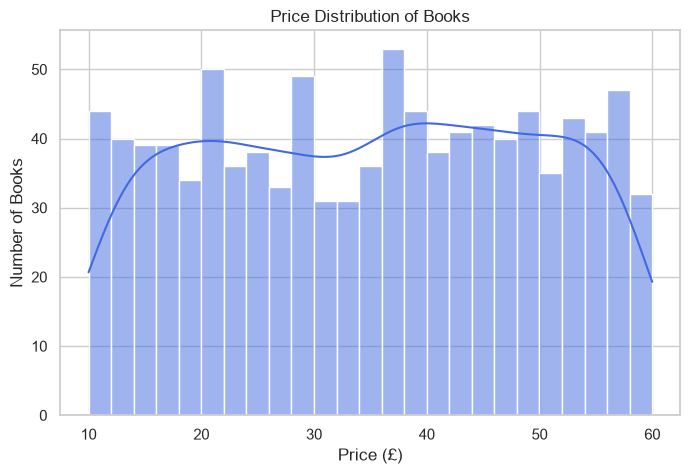

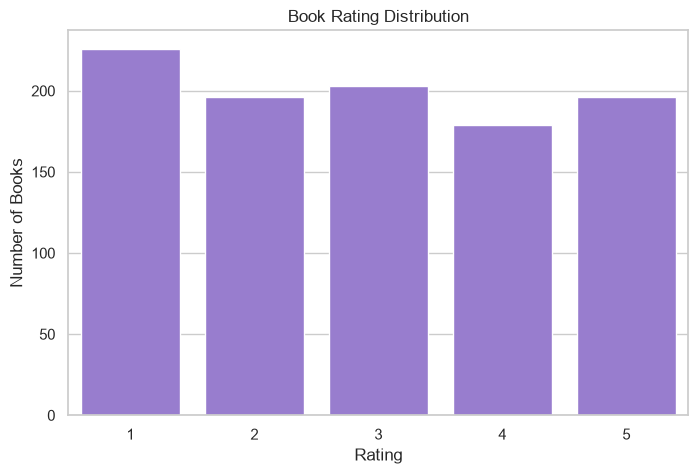

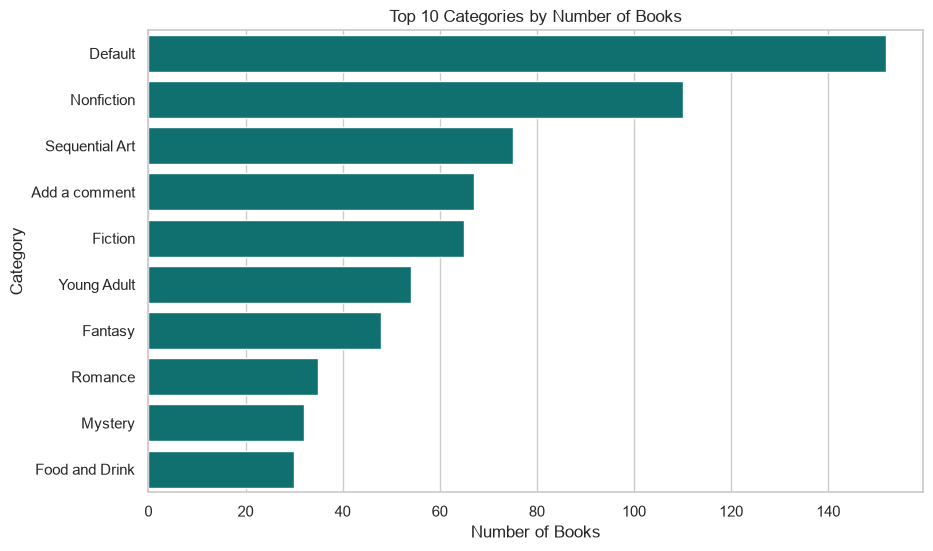

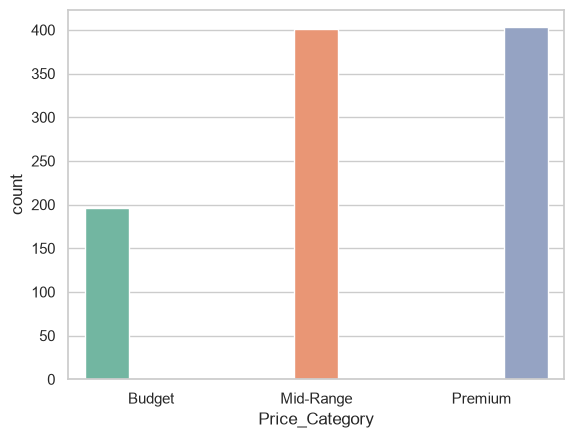

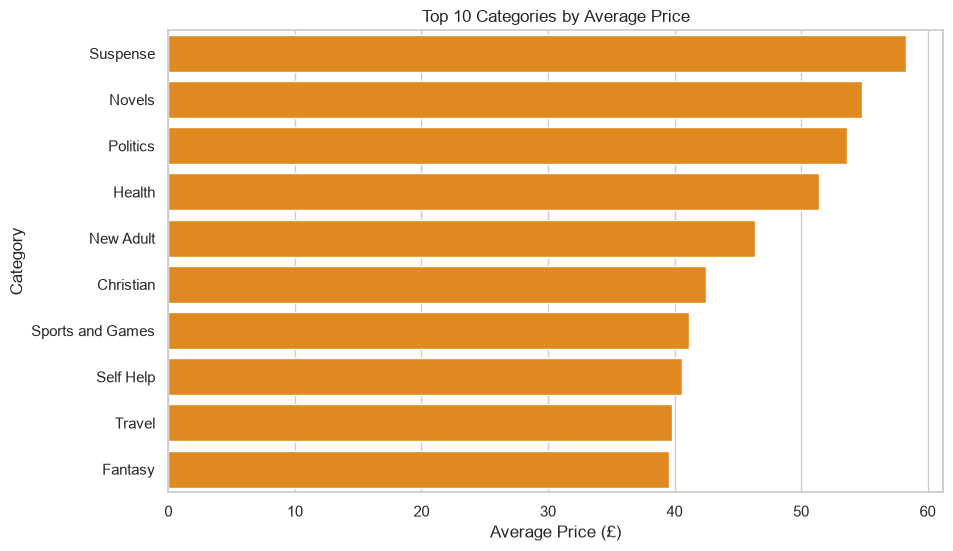

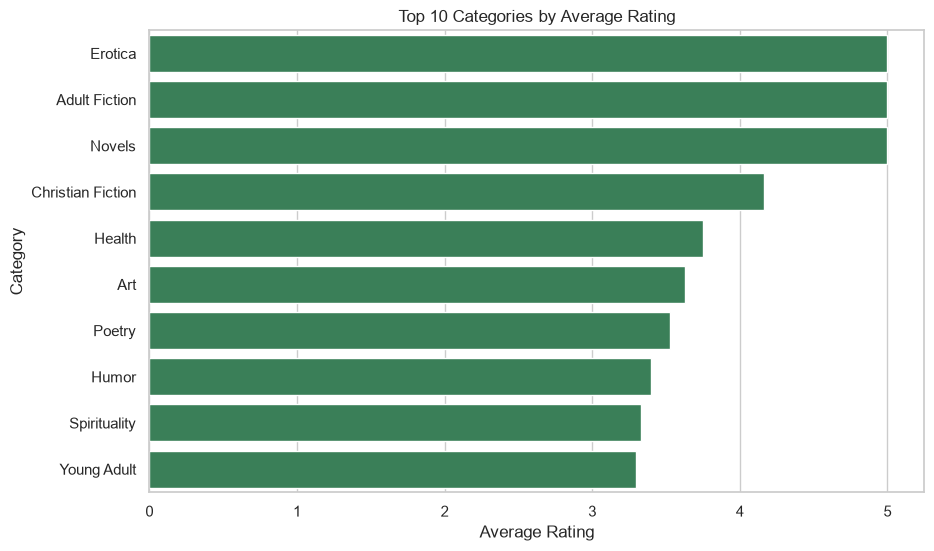

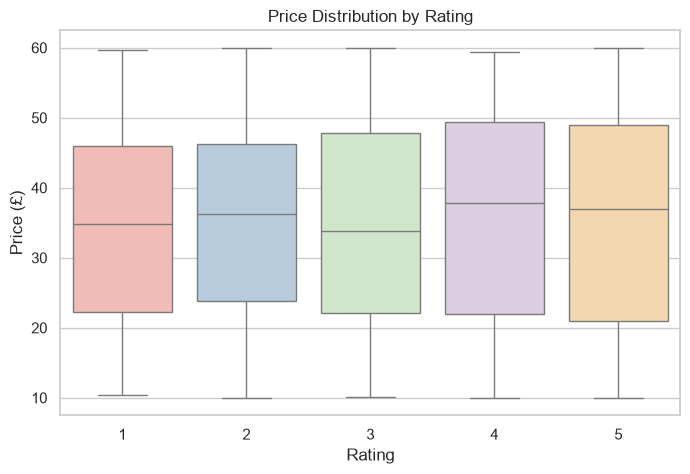

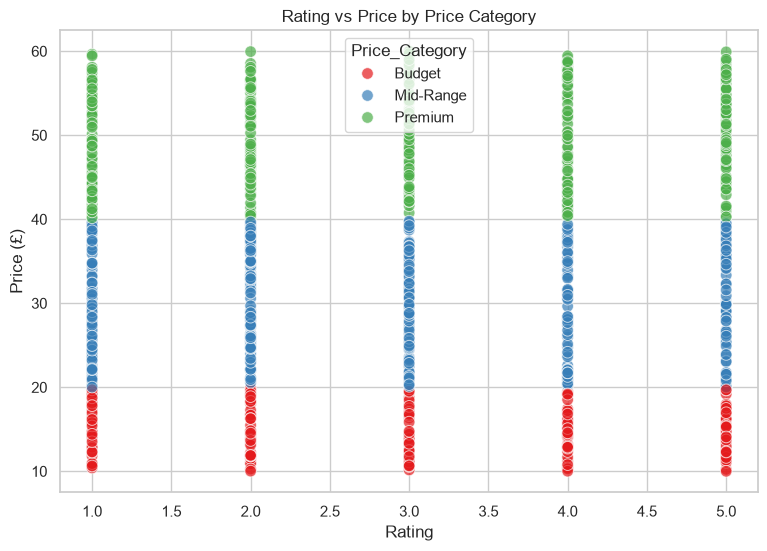

All 8 visualizations have been saved in the 'visualizations' folder.


In [10]:
import os

os.makedirs("visualizations", exist_ok=True)
sns.set_theme(style="whitegrid")

# 1. Price distribution
plt.figure(figsize=(8, 5))
sns.histplot(clean_df["Price"], bins=25, kde=True, color="royalblue")
plt.title("Price Distribution of Books")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.savefig("visualizations/01_price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Rating distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=clean_df, x="Rating", color="mediumpurple")
plt.title("Book Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.savefig("visualizations/02_rating_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Top 10 categories by book count
top_categories = clean_df["Category"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, color="teal")
plt.title("Top 10 Categories by Number of Books")
plt.xlabel("Number of Books")
plt.ylabel("Category")
plt.savefig("visualizations/03_top_categories.png", dpi=300, bbox_inches="tight")
plt.show()

# 4. Price category distribution
sns.countplot(
    data=clean_df,
    x="Price_Category",
    hue="Price_Category",
    order=["Budget", "Mid-Range", "Premium"],
    palette="Set2",
    legend=False
)

# 5. Average price by category
avg_price_category = (
    clean_df.groupby("Category")["Price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_price_category.values, y=avg_price_category.index, color="darkorange")
plt.title("Top 10 Categories by Average Price")
plt.xlabel("Average Price (£)")
plt.ylabel("Category")
plt.savefig("visualizations/05_average_price_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

# 6. Average rating by category
avg_rating_category = (
    clean_df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_rating_category.values, y=avg_rating_category.index, color="seagreen")
plt.title("Top 10 Categories by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.savefig("visualizations/06_average_rating_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

# 7. Price by rating
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=clean_df,
    x="Rating",
    y="Price",
    hue="Rating",
    palette="Pastel1",
    legend=False
)
plt.title("Price Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.savefig("visualizations/07_price_by_rating.png", dpi=300, bbox_inches="tight")
plt.show()

# 8. Rating vs Price with price category
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=clean_df,
    x="Rating",
    y="Price",
    hue="Price_Category",
    palette="Set1",
    alpha=0.7,
    s=70
)
plt.title("Rating vs Price by Price Category")
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.savefig("visualizations/08_rating_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()

print("All 8 visualizations have been saved in the 'visualizations' folder.")

In [11]:
# Business Questions and Answers

total_books = len(clean_df)
total_categories = clean_df["Category"].nunique()
average_price = clean_df["Price"].mean()

most_books_category = clean_df["Category"].value_counts().idxmax()
most_books_count = clean_df["Category"].value_counts().max()

avg_price_by_category = clean_df.groupby("Category")["Price"].mean()

highest_avg_price_category = avg_price_by_category.idxmax()
highest_avg_price = avg_price_by_category.max()

lowest_avg_price_category = avg_price_by_category.idxmin()
lowest_avg_price = avg_price_by_category.min()

most_common_rating = clean_df["Rating"].value_counts().idxmax()
most_common_rating_count = clean_df["Rating"].value_counts().max()

most_expensive_book = clean_df.loc[clean_df["Price"].idxmax()]
cheapest_book = clean_df.loc[clean_df["Price"].idxmin()]

premium_count = (clean_df["Price_Category"] == "Premium").sum()
budget_count = (clean_df["Price_Category"] == "Budget").sum()

price_rating_correlation = clean_df["Price"].corr(clean_df["Rating"])

business_answers = pd.DataFrame({
    "Business Question": [
        "1. How many books were scraped?",
        "2. How many book categories are available?",
        "3. What is the average book price?",
        "4. Which category has the most books?",
        "5. Which category has the highest average price?",
        "6. Which category has the lowest average price?",
        "7. Which rating is most common?",
        "8. What is the most expensive book?",
        "9. What is the cheapest book?",
        "10. Is there a relationship between price and rating?"
    ],
    "Answer": [
        f"{total_books} books were scraped.",
        f"{total_categories} categories are available.",
        f"£{average_price:.2f}",
        f"{most_books_category} with {most_books_count} books.",
        f"{highest_avg_price_category} with an average price of £{highest_avg_price:.2f}.",
        f"{lowest_avg_price_category} with an average price of £{lowest_avg_price:.2f}.",
        f"{int(most_common_rating)}-star rating with {most_common_rating_count} books.",
        f"{most_expensive_book['Title']} — £{most_expensive_book['Price']:.2f}",
        f"{cheapest_book['Title']} — £{cheapest_book['Price']:.2f}",
        f"Price-rating correlation: {price_rating_correlation:.2f}"
    ]
})

display(business_answers)

business_answers.to_csv("business_questions_answers.csv", index=False)

print("Business questions and answers saved successfully!")

,Business Question,Answer
0,1. How many books were scraped?,1000 books were scraped.
1,2. How many book categories are available?,50 categories are available.
2,3. What is the average book price?,£35.07
3,4. Which category has the most books?,Default with 152 books.
4,5. Which category has the highest average price?,Suspense with an average price of £58.33.
5,6. Which category has the lowest average price?,Crime with an average price of £10.97.
6,7. Which rating is most common?,1-star rating with 226 books.
7,8. What is the most expensive book?,The Perfect Play (Play by Play #1) — £59.99
8,9. What is the cheapest book?,An Abundance of Katherines — £10.00
9,10. Is there a relationship between price and ...,Price-rating correlation: 0.03


Business questions and answers saved successfully!


In [12]:
business_insights = [
    "1. The dataset contains 1,000 books across 50 categories, providing a broad catalogue for analysis.",
    "2. The overall average book price is £35.07.",
    "3. The Default category has the largest catalogue, with 152 books.",
    "4. Suspense has the highest average book price at £58.33, indicating a premium-priced category in this dataset.",
    "5. Crime has the lowest average book price at £10.97, making it the most affordable category on average.",
    "6. One-star books are the most common rating group, with 226 books.",
    "7. The Perfect Play (Play by Play #1) is the most expensive book at £59.99, while An Abundance of Katherines is the cheapest at £10.00.",
    "8. The price-rating correlation is 0.03, which indicates almost no relationship between book price and rating."
]

recommendations = [
    "1. Review the large Default category and assign books to more specific categories where possible for better catalogue organisation.",
    "2. Promote affordable Crime books to attract price-sensitive customers.",
    "3. Review premium pricing in the Suspense category and ensure higher prices are supported by customer value.",
    "4. Investigate low-rated books and improve quality, descriptions, or customer experience before promoting them heavily.",
    "5. Do not assume expensive books have better ratings; use rating and price together when designing promotions."
]

print("BUSINESS INSIGHTS")
for insight in business_insights:
    print(insight)

print("\nRECOMMENDATIONS")
for recommendation in recommendations:
    print(recommendation)

project_summary = pd.DataFrame({
    "Type": ["Business Insight"] * len(business_insights) + ["Recommendation"] * len(recommendations),
    "Statement": business_insights + recommendations
})

project_summary.to_csv("business_insights_recommendations.csv", index=False)

print("\nBusiness insights and recommendations saved successfully!")

BUSINESS INSIGHTS
1. The dataset contains 1,000 books across 50 categories, providing a broad catalogue for analysis.
2. The overall average book price is £35.07.
3. The Default category has the largest catalogue, with 152 books.
4. Suspense has the highest average book price at £58.33, indicating a premium-priced category in this dataset.
5. Crime has the lowest average book price at £10.97, making it the most affordable category on average.
6. One-star books are the most common rating group, with 226 books.
7. The Perfect Play (Play by Play #1) is the most expensive book at £59.99, while An Abundance of Katherines is the cheapest at £10.00.
8. The price-rating correlation is 0.03, which indicates almost no relationship between book price and rating.

RECOMMENDATIONS
1. Review the large Default category and assign books to more specific categories where possible for better catalogue organisation.
2. Promote affordable Crime books to attract price-sensitive customers.
3. Review premium

Note: Books to Scrape is a demo website. Its prices and ratings are randomly assigned, so this project demonstrates the end-to-end web-scraping and EDA workflow rather than real commercial market behaviour.

In [13]:
from pathlib import Path
import zipfile

files_to_zip = [
    "books_raw.csv",
    "books_cleaned.csv",
    "business_questions_answers.csv",
    "business_insights_recommendations.csv",
    "Books Market Analysis using EDA.pptx"   # Added PowerPoint
]

notebooks = list(Path(".").glob("*.ipynb"))

with zipfile.ZipFile("Books_Market_Analysis_Submission.zip", "w") as zip_file:

    # Add CSV and PPT files
    for file_name in files_to_zip:
        if Path(file_name).exists():
            zip_file.write(file_name)
        else:
            print(f"Warning: {file_name} not found.")

    # Add all Jupyter notebooks
    for notebook in notebooks:
        zip_file.write(notebook)

    # Add visualization images
    visualizations = Path("visualizations")
    if visualizations.exists():
        for image_file in visualizations.glob("*.png"):
            zip_file.write(image_file)

print("ZIP file created successfully: Books_Market_Analysis_Submission.zip")

ZIP file created successfully: Books_Market_Analysis_Submission.zip
